<a href="https://colab.research.google.com/github/saadsarfraz438/migraine-prediction-ml/blob/main/Maigraine_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project** **Title**: **Maigraine** **Prediction** **ML**




#2. Data Collection / Dataset

In [ ]:
# ============================================
# 1. Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Processed and engineered dataset.xlsx to Processed and engineered dataset.xlsx


In [ ]:
# ============================================
# 2. Load Dataset
# ============================================

# Updated filename to match the uploaded file
df = pd.read_excel("Processed and engineered dataset.xlsx")

# Display first 5 rows
display(df.head())

,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
0,2,1.0,7.0,7,2,1,0,0
1,2,3.0,5.5,7,1,1,0,0
2,2,7.0,7.0,7,2,1,0,1
3,3,7.0,5.5,7,3,2,0,0
4,1,3.0,7.0,9,2,2,0,0


In [ ]:
# This step loads the migraine survey dataset
# and displays the first five rows to understand
# the structure of the data.

In [ ]:
# ============================================
# 3. Dataset Size
# ============================================

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 100
Number of Columns: 8


In [ ]:
# This step helps understand dataset size
# by showing total rows and columns.

In [ ]:
# ============================================
# 4. Dataset Information
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Age                                             100 non-null    int64  
 1   Average Screen Exposure (per day)               100 non-null    float64
 2   Average Sleep Hours Per Night                   100 non-null    float64
 3   Daily water intake                              100 non-null    int64  
 4   Average Stress Level                            100 non-null    int64  
 5   Do you experience frequent anxiety or tension?  100 non-null    int64  
 6   Family History of Migraines?                    100 non-null    int64  
 7   Do you experience migraines? 9(Y)               100 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 6.4 KB


In [ ]:
# This shows:
# - Column names
# - Data types
# - Missing values

In [ ]:
# ============================================
# 5. Statistical Summary
# ============================================

df.describe()

,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.00000,100.000000
mean,2.080000,4.585000,6.800000,5.900000,2.020000,1.15000,0.21000,0.380000
std,0.646357,1.987404,1.612765,2.134375,0.791112,0.74366,0.40936,0.487832
min,1.000000,1.000000,4.000000,3.000000,1.000000,0.00000,0.00000,0.000000
25%,2.000000,3.500000,5.500000,5.000000,1.000000,1.00000,0.00000,0.000000
50%,2.000000,5.500000,7.000000,5.000000,2.000000,1.00000,0.00000,0.000000
75%,2.000000,5.500000,9.000000,7.000000,3.000000,2.00000,0.00000,1.000000
max,4.000000,7.000000,9.000000,9.000000,3.000000,2.00000,1.00000,1.000000


In [ ]:
# This provides statistical information
# such as mean, minimum, maximum,
# and standard deviation.

In [ ]:
# ============================================
# 6. Missing Values
# ============================================

df.isnull().sum()

,0
Age,0
Average Screen Exposure (per day),0
Average Sleep Hours Per Night,0
Daily water intake,0
Average Stress Level,0
Do you experience frequent anxiety or tension?,0
Family History of Migraines?,0
Do you experience migraines? 9(Y),0


# 3.Data Preprocessing
In this section, the raw migraine survey dataset is cleaned and transformed into a machine learning-ready format.

In [ ]:

# ============================================
# View Dataset Columns
# ============================================

df.columns

Index(['Age', 'Average Screen Exposure (per day)',
       'Average Sleep Hours Per Night', 'Daily water intake',
       'Average Stress Level',
       'Do you experience frequent anxiety or tension?',
       'Family History of Migraines?', 'Do you experience migraines? 9(Y)'],
      dtype='object')

In [ ]:
# ============================================
# Remove Unnecessary Columns
# ============================================

# We check if columns exist before dropping to avoid KeyErrors
cols_to_drop = ['Timestamp', 'Name']
existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]

if existing_cols_to_drop:
    df.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"Dropped columns: {existing_cols_to_drop}")
else:
    print("Columns 'Timestamp' and 'Name' were not found; skipping drop step.")

display(df.head())

Columns 'Timestamp' and 'Name' were not found; skipping drop step.


,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
0,2,1.0,7.0,7,2,1,0,0
1,2,3.0,5.5,7,1,1,0,0
2,2,7.0,7.0,7,2,1,0,1
3,3,7.0,5.5,7,3,2,0,0
4,1,3.0,7.0,9,2,2,0,0


Timestamp and Name columns were removed because they do not contribute to migraine prediction and may introduce unnecessary noise into the model.

In [ ]:
# ============================================
# Check Missing Values
# ============================================

df.isnull().sum()

,0
Age,0
Average Screen Exposure (per day),0
Average Sleep Hours Per Night,0
Daily water intake,0
Average Stress Level,0
Do you experience frequent anxiety or tension?,0
Family History of Migraines?,0
Do you experience migraines? 9(Y),0


In [ ]:
# ============================================
# Handle Missing Values
# ============================================

for column in df.columns:

    # Numerical Columns
    if df[column].dtype in ['int64', 'float64']:
        df[column].fillna(df[column].mean(), inplace=True)

    # Categorical Columns
    else:
        df[column].fillna(df[column].mode()[0], inplace=True)

# Check Again
df.isnull().sum()

/tmp/ipykernel_6884/1955078379.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


,0
Age,0
Average Screen Exposure (per day),0
Average Sleep Hours Per Night,0
Daily water intake,0
Average Stress Level,0
Do you experience frequent anxiety or tension?,0
Family History of Migraines?,0
Do you experience migraines? 9(Y),0


Missing values were handled to ensure dataset completeness. Numerical columns were filled using mean values, while categorical columns were filled using mode values.

In [ ]:
# ============================================
# Check Duplicate Records
# ============================================

print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicate Rows: 7
Duplicates Removed Successfully


In [ ]:
# ============================================
# Standardize Text Data
# ============================================

for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].astype(str).str.strip().str.lower()

df.head()

,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
0,2,1.0,7.0,7,2,1,0,0
1,2,3.0,5.5,7,1,1,0,0
2,2,7.0,7.0,7,2,1,0,1
3,3,7.0,5.5,7,3,2,0,0
4,1,3.0,7.0,9,2,2,0,0


In [ ]:
# ============================================
# Convert Range Values to Numeric
# ============================================

range_mapping = {

    'less than 2 hours': 1,
    '2–5 hours': 3.5,
    '2-5 hours': 3.5,
    '5–6 hours': 5.5,
    '5-6 hours': 5.5,
    'more than 6 hours': 7,

    'low': 1,
    'medium': 2,
    'high': 3,

    'no': 0,
    'sometimes': 1,
    'yes': 2
}

df.replace(range_mapping, inplace=True)

df.head()

,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
0,2,1.0,7.0,7,2,1,0,0
1,2,3.0,5.5,7,1,1,0,0
2,2,7.0,7.0,7,2,1,0,1
3,3,7.0,5.5,7,3,2,0,0
4,1,3.0,7.0,9,2,2,0,0


In [ ]:
# ============================================
# Label Encoding
# ============================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

df.head()

,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
0,2,1.0,7.0,7,2,1,0,0
1,2,3.0,5.5,7,1,1,0,0
2,2,7.0,7.0,7,2,1,0,1
3,3,7.0,5.5,7,3,2,0,0
4,1,3.0,7.0,9,2,2,0,0


In [ ]:
# ============================================
# Final Dataset Information
# ============================================

df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 0 to 98
Data columns (total 8 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Age                                             93 non-null     int64  
 1   Average Screen Exposure (per day)               93 non-null     float64
 2   Average Sleep Hours Per Night                   93 non-null     float64
 3   Daily water intake                              93 non-null     int64  
 4   Average Stress Level                            93 non-null     int64  
 5   Do you experience frequent anxiety or tension?  93 non-null     int64  
 6   Family History of Migraines?                    93 non-null     int64  
 7   Do you experience migraines? 9(Y)               93 non-null     int64  
dtypes: float64(2), int64(6)
memory usage: 6.5 KB


,Age,Average Screen Exposure (per day),Average Sleep Hours Per Night,Daily water intake,Average Stress Level,Do you experience frequent anxiety or tension?,Family History of Migraines?,Do you experience migraines? 9(Y)
0,2,1.0,7.0,7,2,1,0,0
1,2,3.0,5.5,7,1,1,0,0
2,2,7.0,7.0,7,2,1,0,1
3,3,7.0,5.5,7,3,2,0,0
4,1,3.0,7.0,9,2,2,0,0


In [ ]:
# ============================================
# Save Cleaned Dataset
# ============================================

df.to_csv("processed_migraine_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


### Interpretation

After preprocessing, the dataset became clean, structured, and suitable for machine learning. Missing values were handled, duplicate records were removed, categorical variables were encoded, and range-based responses were converted into numerical values. This prepared the dataset for exploratory data analysis and model training.

#4. Exploratory Data Analysis (EDA)

# EDA Structure

1. Target Variable Distribution
2. Histograms
3. Bar Charts
4. Box Plots
5. Scatter Plots
6. Correlation Heatmap

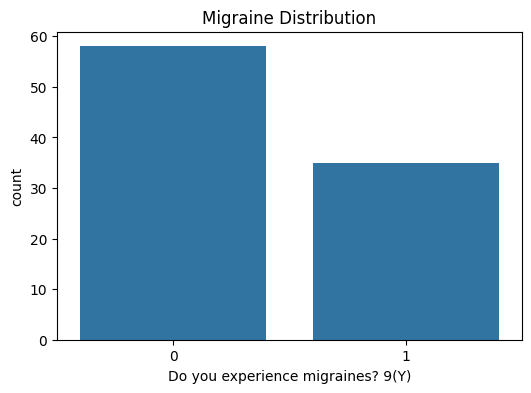

In [ ]:
# ============================================
# Migraine Distribution
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(x='Do you experience migraines? 9(Y)', data=df)

plt.title("Migraine Distribution")
plt.show()

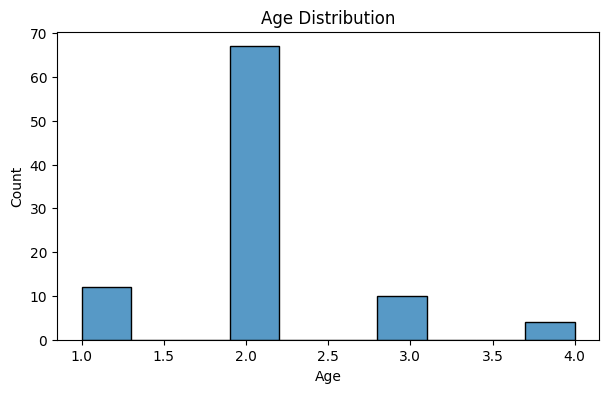

In [ ]:
plt.figure(figsize=(7,4))

sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution")
plt.show()

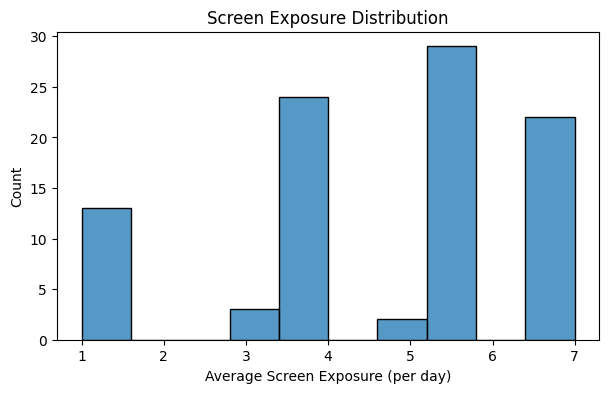

In [ ]:
plt.figure(figsize=(7,4))

sns.histplot(df['Average Screen Exposure (per day)'], bins=10)

plt.title("Screen Exposure Distribution")
plt.show()

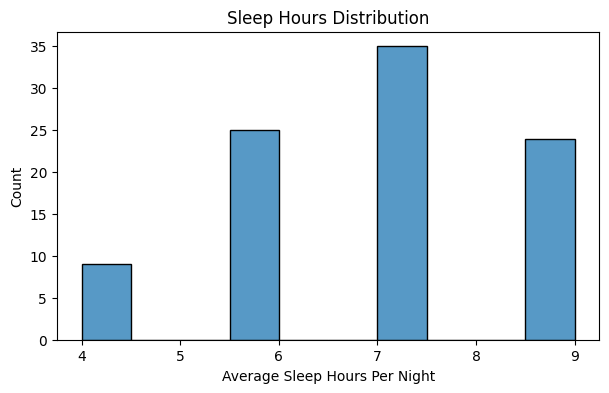

In [ ]:
plt.figure(figsize=(7,4))

sns.histplot(df['Average Sleep Hours Per Night'], bins=10)

plt.title("Sleep Hours Distribution")
plt.show()

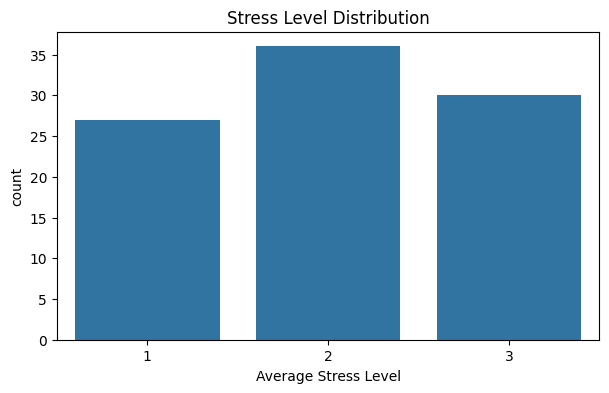

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(x='Average Stress Level', data=df)

plt.title("Stress Level Distribution")
plt.show()

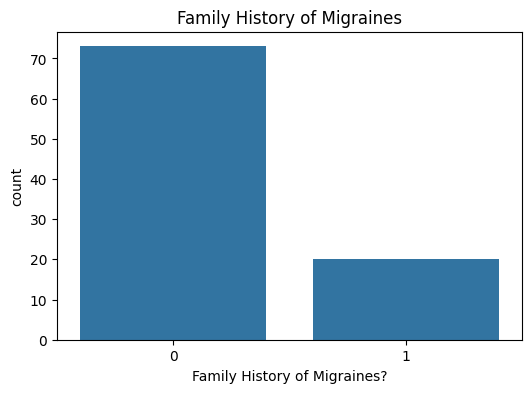

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Family History of Migraines?', data=df)

plt.title("Family History of Migraines")
plt.show()

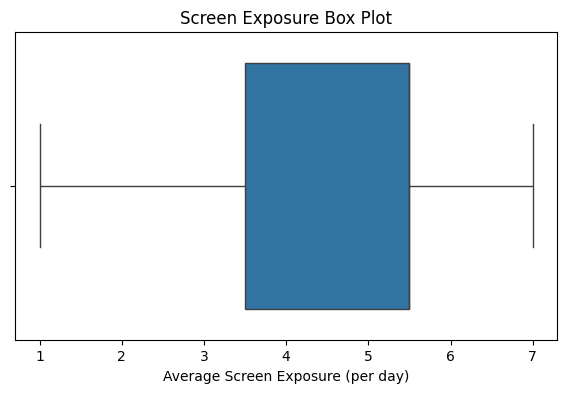

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df['Average Screen Exposure (per day)'])

plt.title("Screen Exposure Box Plot")
plt.show()

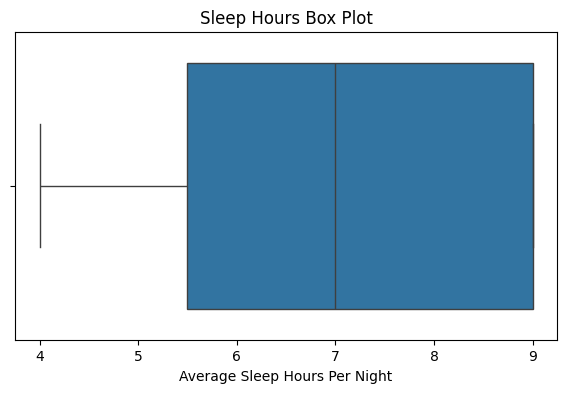

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df['Average Sleep Hours Per Night'])

plt.title("Sleep Hours Box Plot")
plt.show()

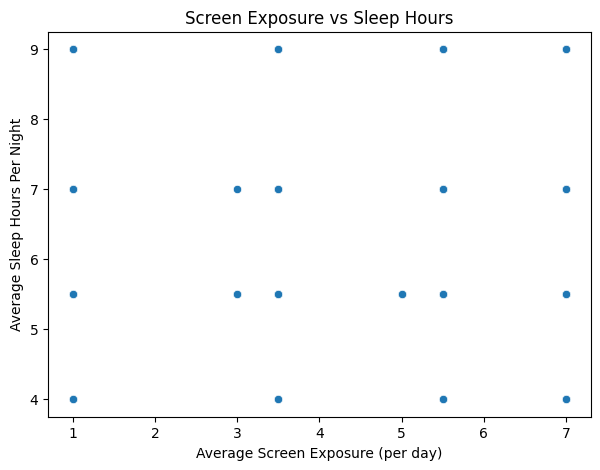

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='Average Screen Exposure (per day)',
    y='Average Sleep Hours Per Night',
    data=df
)

plt.title("Screen Exposure vs Sleep Hours")
plt.show()

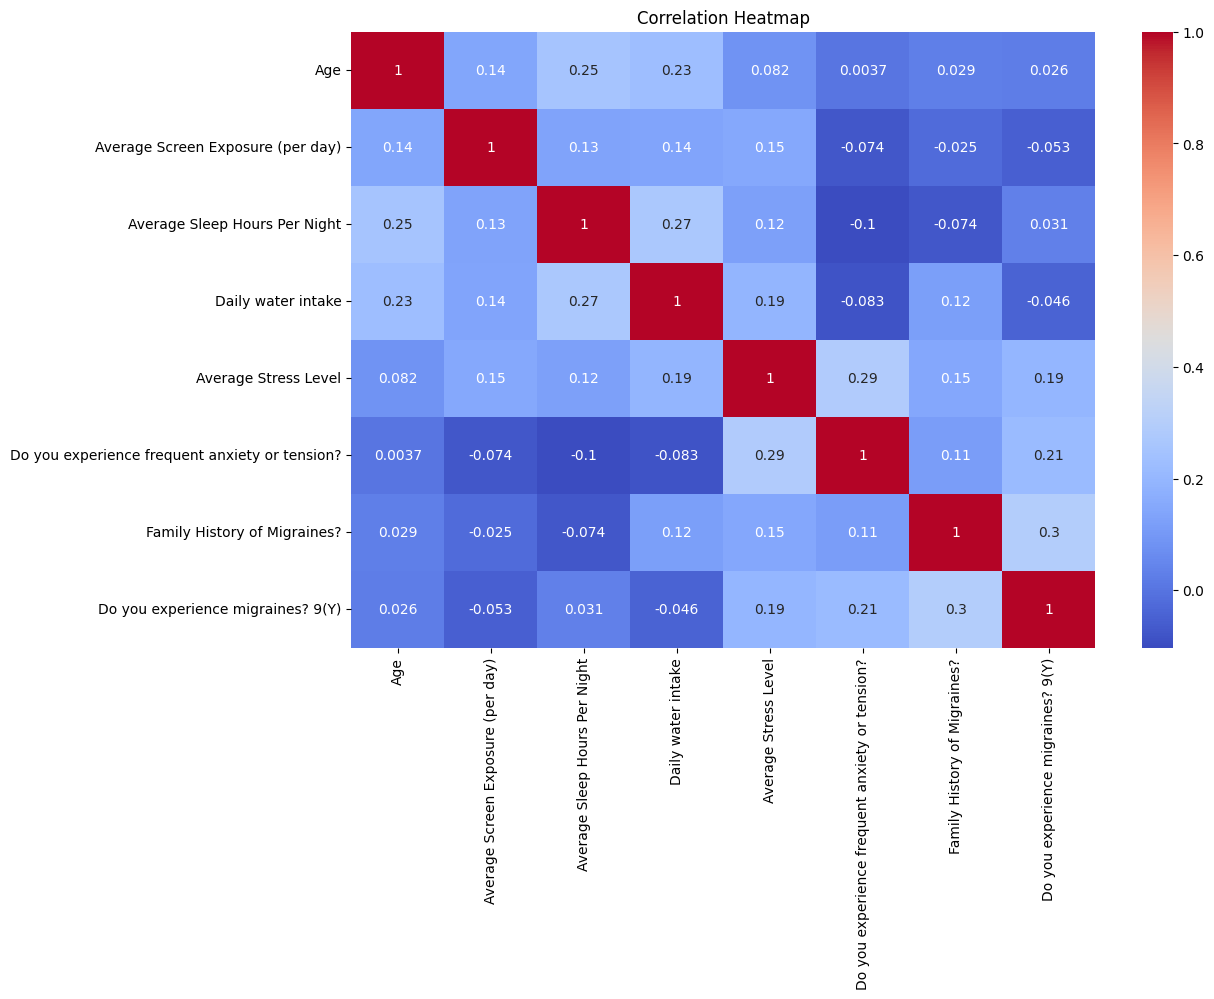

In [ ]:
# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

#5. Machine Learning Model

The dataset was divided into input features (X) and target variable (Y). The target variable represents migraine occurrence, while all remaining columns are used as predictors.

In [ ]:
# ============================================
# Feature Selection
# ============================================

X = df.drop('Do you experience migraines? 9(Y)', axis=1)

y = df['Do you experience migraines? 9(Y)']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (93, 7)
Target Shape: (93,)


In [ ]:
from sklearn.model_selection import train_test_split

# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (74, 7)
Testing Data: (19, 7)


In [ ]:
from sklearn.preprocessing import StandardScaler

# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# — Feature Scaling
# Important for:

# Logistic Regression
# KNN
# Neural Network

#MODEL 1 — LOGISTIC REGRESSION
For a classification problem, Logistic Regression is more appropriate than Linear Regression.)

In [ ]:

from sklearn.linear_model import LogisticRegression

# ============================================
# Logistic Regression
# ============================================

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

#MODEL 2 — DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# ============================================
# Decision Tree
# ============================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

#MODEL 3 — RANDOM FOREST

This will be our best model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ============================================
# Random Forest
# ============================================

# Define the parameter grid to search with an expanded range for n_estimators and min_samples_split
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 8, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Train the Random Forest model with the best parameters
model = RandomForestClassifier(**best_params, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
rf_pred = model.predict(X_test)

# Evaluate the model's accuracy on the test set
accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy with tuned Random Forest:", accuracy)

Best parameters found: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation accuracy: 0.6762
Accuracy with tuned Random Forest: 0.8421052631578947


#MODEL 4 — KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# ============================================
# KNN
# ============================================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

#MODEL 5 — LINEAR REGRESSION
 Rubric explicitly requires it.

Even though migraine prediction is classification, implement it and convert predictions into classes.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# ============================================
# Linear Regression
# ============================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

# Convert predictions into classes

lr_pred_class = np.where(lr_pred >= 0.5, 1, 0)

#MODEL 6 — NEURAL NETWORK

In [ ]:
from sklearn.neural_network import MLPClassifier

# ============================================
# Neural Network
# ============================================

nn_model = MLPClassifier(
    hidden_layer_sizes=(50,50),
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

nn_pred = nn_model.predict(X_test_scaled)

#6.MODEL EVALUATION & MODEL COMPARISON

#STEP 1 — Import Evaluation Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#STEP 2 — Create Evaluation Function

In [ ]:
def evaluate_model(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-"*30)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    return [model_name, accuracy, precision, recall, f1]

#STEP 3 — Evaluate All Models

In [ ]:
results = []

results.append(
    evaluate_model(y_test, lr_pred_class,
                   "Linear Regression")
)

results.append(
    evaluate_model(y_test, log_pred,
                   "Logistic Regression")
)

results.append(
    evaluate_model(y_test, dt_pred,
                   "Decision Tree")
)

# Updated with the latest rf_pred from the tuned model
results.append(
    evaluate_model(y_test, rf_pred,
                   "Random Forest")
)

results.append(
    evaluate_model(y_test, knn_pred,
                   "KNN")
)

results.append(
    evaluate_model(y_test, nn_pred,
                   "Neural Network")
)


Linear Regression
------------------------------
Accuracy : 0.7894736842105263
Precision: 0.75
Recall   : 0.5
F1 Score : 0.6

Logistic Regression
------------------------------
Accuracy : 0.7894736842105263
Precision: 0.75
Recall   : 0.5
F1 Score : 0.6

Decision Tree
------------------------------
Accuracy : 0.5789473684210527
Precision: 0.3333333333333333
Recall   : 0.3333333333333333
F1 Score : 0.3333333333333333

Random Forest
------------------------------
Accuracy : 0.8421052631578947
Precision: 1.0
Recall   : 0.5
F1 Score : 0.6666666666666666

KNN
------------------------------
Accuracy : 0.7894736842105263
Precision: 1.0
Recall   : 0.3333333333333333
F1 Score : 0.5

Neural Network
------------------------------
Accuracy : 0.7894736842105263
Precision: 0.75
Recall   : 0.5
F1 Score : 0.6


#STEP 4 — Create Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear Regression,0.789474,0.750000,0.500000,0.600000
1,Logistic Regression,0.789474,0.750000,0.500000,0.600000
2,Decision Tree,0.578947,0.333333,0.333333,0.333333
3,Random Forest,0.842105,1.000000,0.500000,0.666667
4,KNN,0.789474,1.000000,0.333333,0.500000
5,Neural Network,0.789474,0.750000,0.500000,0.600000


#STEP 5 — Best Model

In [ ]:
best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("Overall Best Model:")
print(best_model)

Overall Best Model:
Model        Random Forest
Accuracy          0.842105
Precision              1.0
Recall                 0.5
F1 Score          0.666667
Name: 3, dtype: object


#STEP 6 — Confusion Matrix (Best Model)

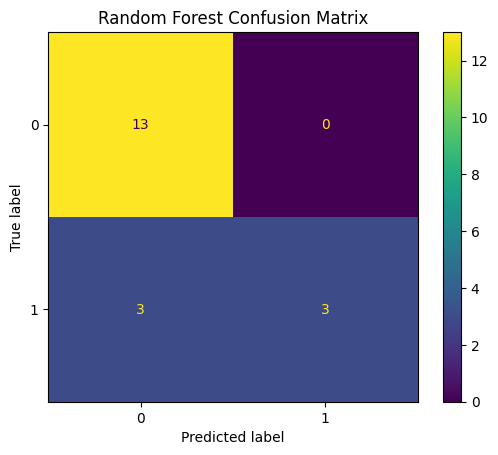

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

#STEP 7 — Accuracy Comparison Graph

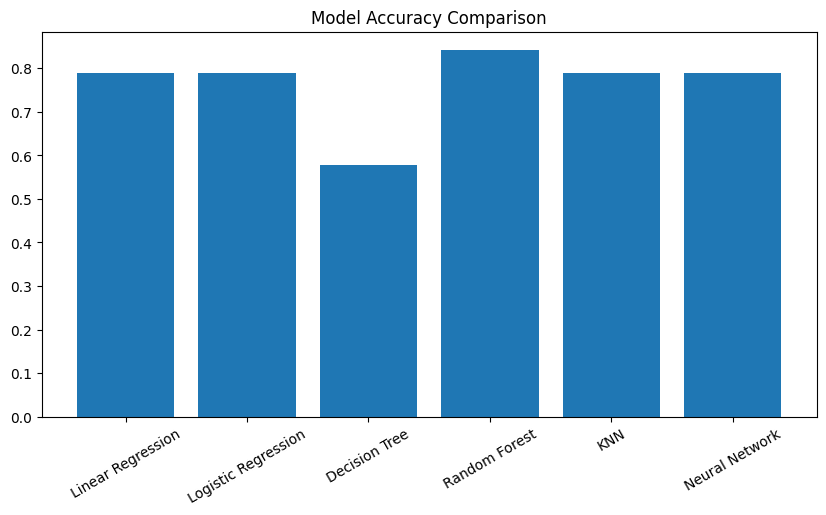

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()